# SharkSafe: Data Wrangling and EDA

**Question:** Which activities and locations appear most frequently in recorded unprovoked shark incidents from 2000–2025, and how do fatal outcomes differ across activity groups?

**Hypothesis:** Surfing will be the most frequently recorded activity.

> This analysis describes reported incidents, not actual risk. Exposure totals are unavailable.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from cleaning import clean_shark_data

sns.set_theme(style='whitegrid')
RAW_PATH = ROOT / 'data' / 'raw' / 'GSAF5.xls'

## 1. Load and inspect the raw data

In [2]:
raw = pd.read_excel(RAW_PATH, sheet_name='Sheet1-GSAF')
print(f'Raw shape: {raw.shape}')
raw.head()

Raw shape: (7117, 23)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
quality_before = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing': raw.isna().sum(),
    'unique': raw.nunique(dropna=True)
}).sort_values('missing', ascending=False)
quality_before

,dtype,missing,unique
Unnamed: 21,str,7116,1
Unnamed: 22,str,7115,2
Time,object,3527,490
Species,str,3131,1768
Age,object,2994,252
Activity,str,583,1617
Sex,str,578,12
Location,str,567,4656
Fatal Y/N,object,561,12
State,str,487,956


## 2. Clean the data

The imported `clean_shark_data` function calls smaller reusable functions in a documented order. It standardizes columns and text, removes exact duplicates, parses dates and ages, standardizes categorical fields, and creates analytical groupings.

In [4]:
clean = clean_shark_data(raw)
print(f'Cleaned shape: {clean.shape}')
print(f'Exact rows removed: {len(raw) - len(clean)}')
clean.head()

Cleaned shape: (7110, 20)
Exact rows removed: 7


,date,year,country,state,location,activity,injury,time,species,unnamed_21,unnamed_22,incident_date,month,decade,sex_clean,age_numeric,age_group,fatal,activity_group,incident_type
0,26th August,2026,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,No injury bump to surfboard,1330hrs,Tiger Shark,NaN,NaN,2026-08-26,August,2020,F,<NA>,Unknown,No,Surfing,Unprovoked
1,23rd August,2026,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,Bite to foot,1700hrs,Large shark,NaN,NaN,2026-08-23,August,2020,M,43,30–44,No,Swimming/Wading,Unprovoked
2,19th August,2026,REUNION ISLAND,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,No injury,?,Bull shark 2.5m (8.2 ft),NaN,NaN,2026-08-19,August,2020,M,<NA>,Unknown,No,Fishing,Provoked
3,11th August,2026,IRELAND,Waterford,Ardemore County,Fishing,Bite to left leg,1615hrs,1.5m (5ft) Blue shark,NaN,NaN,2026-08-11,August,2020,M,27,18–29,No,Fishing,Provoked
4,8th August,2026,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Bite to rescue torpedo sustained no injury,1300hrs,Great White Shark,NaN,NaN,2026-08-08,August,2020,M,71,60+,No,Other/Unknown,Unprovoked


In [5]:
clean[['year', 'incident_date', 'age_numeric', 'age_group',
       'sex_clean', 'fatal', 'activity_group', 'incident_type']].head(10)

,year,incident_date,age_numeric,age_group,sex_clean,fatal,activity_group,incident_type
0,2026,2026-08-26,<NA>,Unknown,F,No,Surfing,Unprovoked
1,2026,2026-08-23,43,30–44,M,No,Swimming/Wading,Unprovoked
2,2026,2026-08-19,<NA>,Unknown,M,No,Fishing,Provoked
3,2026,2026-08-11,27,18–29,M,No,Fishing,Provoked
4,2026,2026-08-08,71,60+,M,No,Other/Unknown,Unprovoked
5,2026,2026-07-29,<NA>,Unknown,M,No,Swimming/Wading,Unprovoked
6,2026,2026-07-25,21,18–29,M,No,Swimming/Wading,Unprovoked
7,2026,2026-07-24,69,60+,M,No,Diving/Snorkeling,Unprovoked
8,2026,2026-07-24,<NA>,Unknown,M,No,Fishing,Unprovoked
9,2026,2026-07-21,<NA>,Unknown,M,No,Other/Unknown,Unprovoked


In [6]:
clean.to_csv(ROOT / 'data' / 'cleaned' / 'shark_attacks_clean.csv', index=False)

## 3. Define the analytical population

We select complete calendar years 2000–2025 and cases classified by GSAF as unprovoked. Excluding 2026 prevents a partial year from being compared with full years.

In [7]:
analysis = clean.loc[
    clean['year'].between(2000, 2025) &
    clean['incident_type'].eq('Unprovoked')
].copy()
print(f'Analysis rows: {len(analysis):,}')

Analysis rows: 2,220


## 4. Exploratory data analysis

In [8]:
activity_counts = analysis['activity_group'].value_counts()
activity_counts

activity_group
Surfing              966
Swimming/Wading      520
Other/Unknown        235
Fishing              230
Diving/Snorkeling    229
Paddling              35
Boating                5
Name: count, dtype: int64

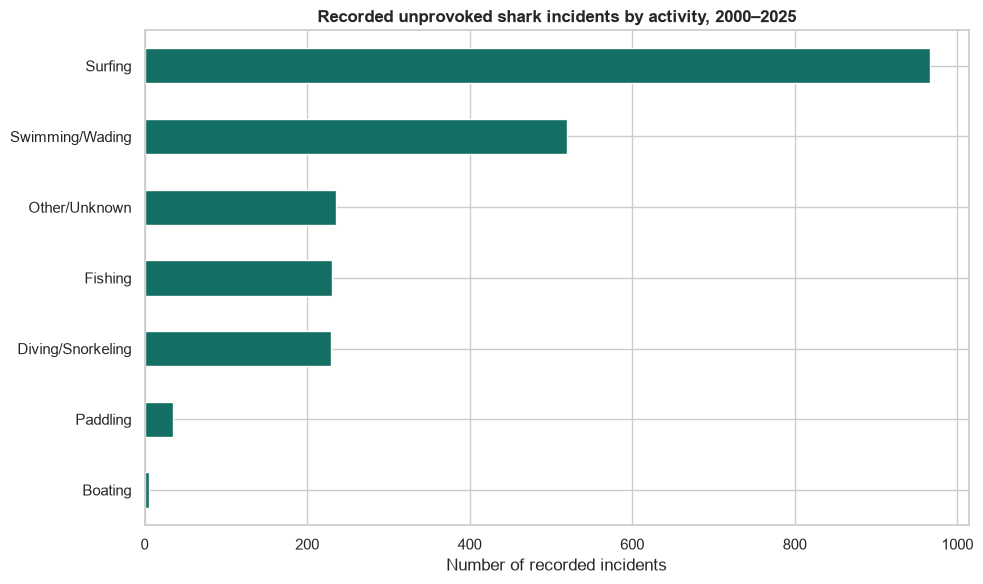

In [9]:
ax = activity_counts.sort_values().plot.barh(figsize=(10, 6), color='#136F63')
ax.set_title('Recorded unprovoked shark incidents by activity, 2000–2025', weight='bold')
ax.set_xlabel('Number of recorded incidents'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [10]:
country_counts = analysis['country'].fillna('Unknown').value_counts().head(10)
country_counts

country
USA                 1125
AUSTRALIA            439
SOUTH AFRICA         115
BAHAMAS               70
BRAZIL                54
NEW ZEALAND           38
NEW CALEDONIA         35
EGYPT                 30
REUNION               28
FRENCH POLYNESIA      27
Name: count, dtype: int64

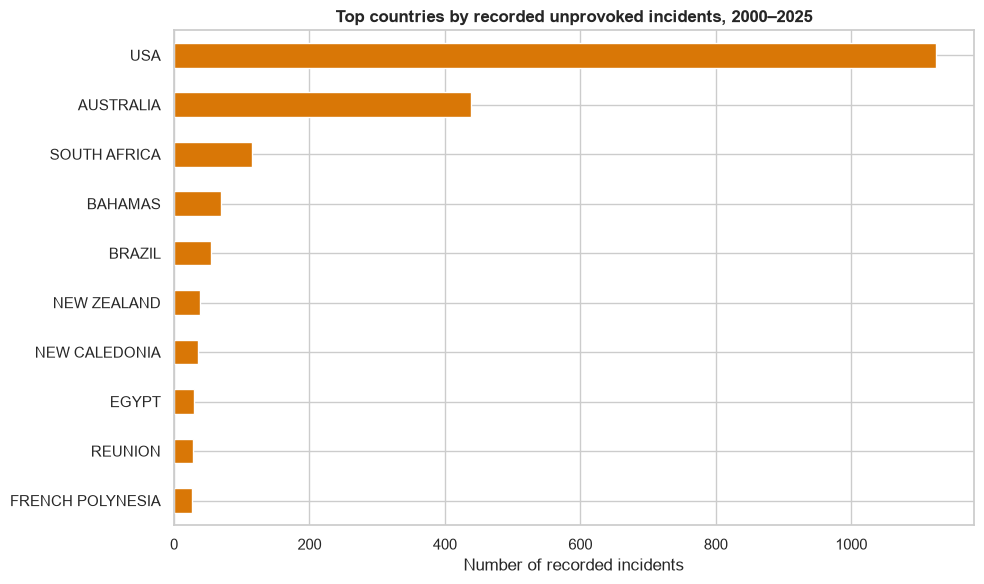

In [11]:
ax = country_counts.sort_values().plot.barh(figsize=(10, 6), color='#D97706')
ax.set_title('Top countries by recorded unprovoked incidents, 2000–2025', weight='bold')
ax.set_xlabel('Number of recorded incidents'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [12]:
known_fatal = analysis[analysis['fatal'].isin(['Yes', 'No'])]
fatal_by_activity = (known_fatal.groupby('activity_group')['fatal']
                     .apply(lambda x: x.eq('Yes').mean() * 100)
                     .sort_values(ascending=False))
print(f'Known outcomes: {len(known_fatal):,}')
print(f'Overall fatal percentage: {known_fatal["fatal"].eq("Yes").mean() * 100:.2f}%')
fatal_by_activity

Known outcomes: 2,203
Overall fatal percentage: 10.80%


activity_group
Diving/Snorkeling    17.857143
Swimming/Wading      14.671815
Fishing              13.596491
Other/Unknown         9.606987
Surfing               6.950207
Paddling              5.714286
Boating               0.000000
Name: fatal, dtype: float64

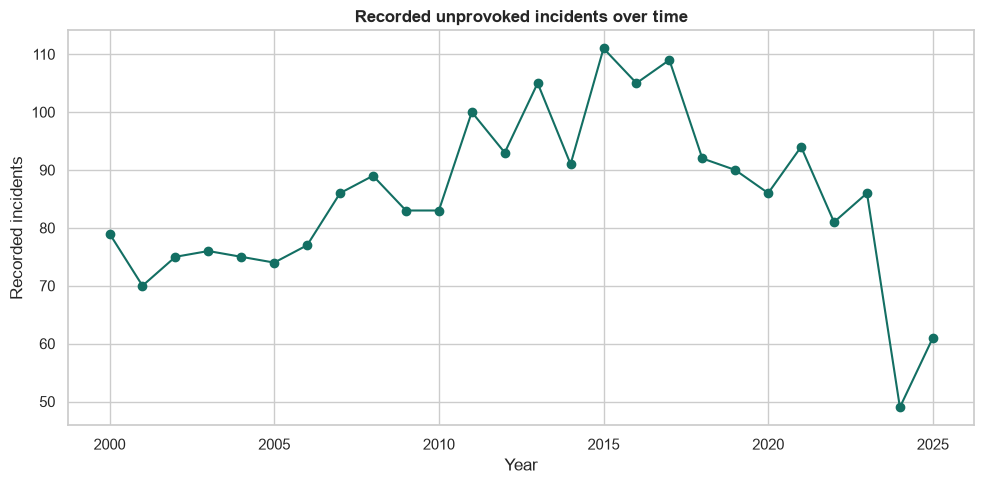

In [13]:
annual = analysis.groupby('year').size()
ax = annual.plot(figsize=(10, 5), marker='o', color='#136F63')
ax.set_title('Recorded unprovoked incidents over time', weight='bold')
ax.set_ylabel('Recorded incidents'); ax.set_xlabel('Year')
plt.tight_layout(); plt.show()

## 5. Conclusion

The hypothesis is **supported within the selected data**: surfing is the most frequently recorded activity group, with **966 of 2,220** modern unprovoked incidents. The USA has the highest recorded count (**1,125**). Among 2,203 records with known outcomes, **10.80%** are fatal.

These figures do not measure personal risk or establish causation. Reporting levels, coastline usage, population, tourism, and participation rates vary substantially. Actual risk estimation would require exposure denominators such as participant-hours by activity and location.